<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Gradient_Descent_Types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Implementation with Gradient Descent

In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## 1. Import Libraries

This section imports the necessary Python libraries for data manipulation, numerical operations, and plotting.

In [12]:
df = pd.read_csv("sample_data/homeprices_Bangalore.csv")
df.head()

,area,bedrooms,price
0,3774,1,158.90
1,1460,1,71.38
2,1894,1,75.80
3,1730,3,101.33
4,1695,1,75.09


## 2. Load and Inspect Data

We load the house price dataset from a CSV file into a pandas DataFrame and display its first few rows to get an initial overview of the data structure.

In [13]:
df.sample(5)

,area,bedrooms,price
153,3414,3,167.61
7,2769,1,123.35
194,2581,2,119.54
115,2095,4,124.99
126,2878,3,141.50


This cell displays a random sample of 5 rows from the DataFrame, which is useful for quickly verifying the data's content and structure beyond just the head or tail.

In [14]:
from sklearn import preprocessing

sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_X = sx.fit_transform(df.drop('price',axis='columns'))
scaled_X

array([[0.93727705, 0.        ],
       [0.24940547, 0.        ],
       [0.37841855, 0.        ],
       [0.32966706, 0.5       ],
       [0.31926278, 0.        ],
       [0.91290131, 0.75      ],
       [0.48067776, 1.        ],
       [0.63852556, 0.        ],
       [0.132283  , 0.5       ],
       [0.3617717 , 0.5       ],
       [0.09185493, 0.        ],
       [0.4343044 , 1.        ],
       [0.62841855, 0.        ],
       [0.93638526, 0.5       ],
       [0.86147444, 0.25      ],
       [0.0324019 , 0.75      ],
       [0.49464923, 0.5       ],
       [0.99851367, 0.        ],
       [0.22235434, 0.75      ],
       [0.70451843, 0.        ],
       [0.44411415, 0.        ],
       [0.84185493, 0.25      ],
       [0.71700357, 0.75      ],
       [0.3549346 , 0.75      ],
       [0.27764566, 0.25      ],
       [0.68460166, 0.5       ],
       [0.34571938, 0.        ],
       [0.13020214, 1.        ],
       [1.        , 0.        ],
       [0.        , 0.        ],
       [0.

## 3. Data Scaling (MinMaxScaler)

Before applying gradient descent, it's crucial to scale the features (`area`, `bedrooms`) and the target variable (`price`). Scaling helps the optimization algorithm converge faster and prevents features with larger numerical ranges from dominating the cost function. We use `MinMaxScaler` to scale values between 0 and 1.

In [15]:
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1))
scaled_y

array([[0.71213139],
       [0.17778863],
       [0.20477441],
       [0.36064473],
       [0.20043959],
       [0.91153306],
       [0.59234385],
       [0.49508517],
       [0.17351487],
       [0.38738629],
       [0.08095732],
       [0.53312168],
       [0.46767202],
       [0.83124733],
       [0.77208621],
       [0.15123023],
       [0.46083399],
       [0.75737224],
       [0.31638073],
       [0.50924965],
       [0.30832163],
       [0.71219244],
       [0.72336528],
       [0.45485072],
       [0.23408022],
       [0.63300568],
       [0.24702363],
       [0.37438183],
       [0.75218267],
       [0.01343183],
       [0.59722816],
       [0.13895842],
       [0.70944502],
       [0.1014714 ],
       [0.41834056],
       [0.83680322],
       [0.43476403],
       [0.55650528],
       [0.29696563],
       [0.45594969],
       [0.24000244],
       [0.8896758 ],
       [0.7373466 ],
       [0.87923561],
       [0.22626534],
       [0.5399597 ],
       [0.29476769],
       [0.913

Similarly, we scale the target variable (`price`) using its own `MinMaxScaler` instance. The `reshape(-1, 1)` is used to convert the 1D array into a 2D array with one column, as required by `fit_transform`.

In [16]:
w = np.ones(shape=(2))

## 4. Gradient Descent Prerequisites

Here, we initialize the weights (`w`) for our linear regression model. Since we have two features (area and bedrooms), we need two weights. We start with both weights as 1s.

In [17]:
scaled_X.T

array([[0.93727705, 0.24940547, 0.37841855, 0.32966706, 0.31926278,
        0.91290131, 0.48067776, 0.63852556, 0.132283  , 0.3617717 ,
        0.09185493, 0.4343044 , 0.62841855, 0.93638526, 0.86147444,
        0.0324019 , 0.49464923, 0.99851367, 0.22235434, 0.70451843,
        0.44411415, 0.84185493, 0.71700357, 0.3549346 , 0.27764566,
        0.68460166, 0.34571938, 0.13020214, 1.        , 0.        ,
        0.6774673 , 0.21581451, 0.85701546, 0.13466112, 0.31539834,
        0.75416171, 0.60225922, 0.81034483, 0.28359096, 0.53061831,
        0.04994055, 0.88703924, 0.80648038, 0.88703924, 0.16082045,
        0.55826397, 0.37039239, 0.84958383, 0.4479786 , 0.94560048,
        0.18579073, 0.60850178, 0.85225922, 0.6519025 , 0.37931034,
        0.7175981 , 0.17211653, 0.69619501, 0.60642093, 0.06539834,
        0.60047562, 0.83323424, 0.77021403, 0.86920333, 0.39892985,
        0.62960761, 0.406956  , 0.88644471, 0.43311534, 0.75356718,
        0.22413793, 0.00386445, 0.66349584, 0.93

This cell demonstrates transposing `scaled_X`. In linear regression, when calculating predictions (`y_predicted = np.dot(w, X.T) + b`), we often need the transpose of the feature matrix `X` to correctly align dimensions for matrix multiplication with the weight vector `w`.

In [18]:
np.dot(w, scaled_X.T)

array([0.93727705, 0.24940547, 0.37841855, 0.82966706, 0.31926278,
       1.66290131, 1.48067776, 0.63852556, 0.632283  , 0.8617717 ,
       0.09185493, 1.4343044 , 0.62841855, 1.43638526, 1.11147444,
       0.7824019 , 0.99464923, 0.99851367, 0.97235434, 0.70451843,
       0.44411415, 1.09185493, 1.46700357, 1.1049346 , 0.52764566,
       1.18460166, 0.34571938, 1.13020214, 1.        , 0.        ,
       1.1774673 , 0.21581451, 1.10701546, 0.38466112, 1.06539834,
       1.75416171, 0.60225922, 0.81034483, 0.78359096, 0.78061831,
       1.04994055, 1.63703924, 1.05648038, 1.63703924, 0.66082045,
       1.05826397, 0.37039239, 1.84958383, 1.1979786 , 1.19560048,
       0.68579073, 0.60850178, 0.85225922, 1.4019025 , 0.87931034,
       1.7175981 , 0.67211653, 1.44619501, 1.35642093, 0.56539834,
       1.35047562, 1.33323424, 1.02021403, 1.36920333, 0.89892985,
       1.37960761, 1.156956  , 0.88644471, 0.43311534, 1.00356718,
       0.22413793, 0.50386445, 1.41349584, 0.93073722, 0.57491

This cell shows a simple dot product operation, which is a core component of calculating `y_predicted` in linear regression (`w1*x1 + w2*x2`).

In [19]:
# quick demo
a = np.array([1,2,3])
b = np.array([10, 5, 7])
a-b

array([-9, -3, -4])

This is a quick demonstration of element-wise subtraction between two NumPy arrays. This operation is fundamental in calculating the error term `(y_true - y_predicted)` in gradient descent.

In [20]:
np.square(a-b)

array([81,  9, 16])

This demonstrates squaring each element of a NumPy array. Squaring the error term `(y_true - y_predicted)` is a key step in calculating the Mean Squared Error (MSE), which is our cost function.

In [21]:
np.mean(np.square(a-b))

np.float64(35.333333333333336)

This shows how to calculate the mean of the squared differences. Together, these last three cells illustrate the components of the Mean Squared Error (MSE) cost function: `np.mean(np.square(y_true - y_predicted))`.

In [22]:
def batch_gradient_descent(X, y_true, epochs, learning_rate=0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape=number_of_features)
    b = 0
    total_samples = X.shape[0]

    cost_list = []
    epoch_list = []

    for i in range(epochs):
        y_predicted = np.dot(w, scaled_X.T) + b # w1 * area + w2 * bedrooms

        w_grad = -(2/total_samples) * (X.T.dot(y_true - y_predicted))
        b_grad = -(2/total_samples) * np.sum(y_true - y_predicted)
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad

        cost = np.mean(np.square(y_true - y_predicted))

        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w, b, cost, cost_list, epoch_list

w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0], ), 500)
w, b, cost



(array([0.88317974, 0.46015351]),
 np.float64(-0.18233290089532742),
 np.float64(0.006601651351194215))

## 5. Batch Gradient Descent Implementation

This section defines and executes the Batch Gradient Descent algorithm. In Batch Gradient Descent, the gradients are calculated using *all* training samples in each iteration to update the weights and bias. This method typically results in a stable convergence but can be computationally expensive for very large datasets.

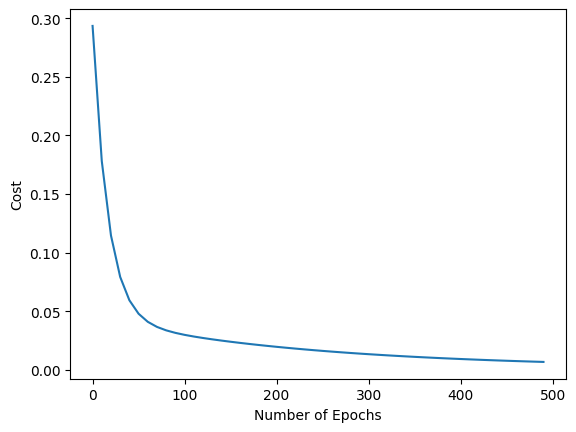

In [23]:
plt.xlabel("Number of Epochs")
plt.ylabel("Cost")
plt.plot(epoch_list, cost_list)

This plot visualizes the reduction in cost (Mean Squared Error) over the training epochs for Batch Gradient Descent. A decreasing cost indicates that the model is learning and converging towards an optimal solution.

In [24]:
sx.transform([[1730, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.32966706, 0.5       ]])

## 6. Making Predictions with Batch Gradient Descent

Before making predictions on new data, we need to apply the same scaling transformation (`sx.transform`) that was used on the training features. This ensures consistency between the training and prediction phases.

In [25]:
w

array([0.88317974, 0.46015351])

This cell displays the final optimized weights (`w`) obtained after running the Batch Gradient Descent algorithm.

In [26]:
sy.inverse_transform([[1,0.5,0]])

array([[206.05 , 124.155,  42.26 ]])

This demonstrates the inverse transformation of scaled values back to their original scale using `sy.inverse_transform`. This is essential to convert the predicted scaled price back into a meaningful house price in the original currency units. Note that `sy` was fitted on a single feature (`price`), but `inverse_transform` can accept multiple scaled values as input, returning their corresponding original values. The example `[[1,0.5,0]]` is used for demonstration purposes.

In [27]:
def predict(area, bedrooms, w,b):
  scaled_X = sx.transform([[area, bedrooms]])[0]
  scaled_price = w[0]*scaled_X[0] + w[1]*scaled_X[1] + b
  return sy.inverse_transform([[scaled_price]])[0][0]

This helper function `predict` encapsulates the entire prediction process: scaling the input features, applying the learned linear model (`w` and `b`), and then inverse transforming the predicted scaled price back to its original scale.

In [28]:
predict(1730, 3, w,b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(97.76828748001279)

Here, we use the `predict` function with the weights and bias found by Batch Gradient Descent to estimate the price of a house with 1730 sqft and 3 bedrooms.

In [29]:
predict (930, 1, w, b) # Predictions from linear regression models are approximations due to the inherent complexity of real-world data and the model's simplicity.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(25.683062430881986)

Another prediction example using the Batch Gradient Descent model for a house with 930 sqft and 1 bedroom.

In [30]:
predict(2082, 5, w, b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(150.58897859936886)

A third prediction example using the Batch Gradient Descent model for a house with 2082 sqft and 5 bedrooms.

In [32]:
predict(1555, 2, w, b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(71.4009431121423)

A final prediction example using the Batch Gradient Descent model for a house with 1555 sqft and 2 bedrooms.

In [36]:
import random
random.randint(0, 6)

3

## 7. Stochastic Gradient Descent Prerequisites

This cell demonstrates the `random.randint` function, which is crucial for Stochastic Gradient Descent (SGD). In SGD, we randomly select a single sample (or a small batch) at each iteration to calculate the gradients, rather than using the entire dataset.

In [38]:
def stochastic_gradient_descent(X, y_true, epochs, learning_rate=0.01):
  number_of_features = X.shape[1]
  # numpy array with 1 row and columns equal to number of features in
  # our case number_of_features = 3 (area, bedroom and age)
  w = np.ones(shape=(number_of_features))
  b = 0
  total_samples = X.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    random_index = random.randint(0, total_samples-1)
    sample_x = X[random_index]
    sample_y = y_true[random_index]
    y_predicted = np.dot(w, sample_x.T) + b
    w_grad = -(2/total_samples) * (sample_y - y_predicted) * sample_x
    b_grad = -(2/total_samples) * (sample_y - y_predicted)
    w = w - learning_rate * w_grad
    b = b - learning_rate * b_grad

    cost = np.mean(np.square(sample_y - y_predicted))

    if i%100==0: # at every 100th iteration record the cost and epoch value
      cost_list.append(cost)
      epoch_list.append(i)
  return w, b, cost, cost_list, epoch_list

w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0], ), 10000)
w_sgd, b_sgd, cost_sgd

(array([0.87207391, 0.81790813]),
 np.float64(-0.2347425694553302),
 np.float64(0.07877095072528147))

## 8. Stochastic Gradient Descent Implementation

This section defines and executes the Stochastic Gradient Descent (SGD) algorithm. Unlike Batch Gradient Descent, SGD updates the model's weights and bias using the gradients calculated from only *one randomly chosen sample* at each iteration. This makes SGD much faster for very large datasets and can help escape local minima, though its convergence path can be more erratic.

In [39]:
w, b, cost

(array([0.88317974, 0.46015351]),
 np.float64(-0.18233290089532742),
 np.float64(0.006601651351194215))

This cell displays the final weights, bias, and cost obtained from the Batch Gradient Descent, allowing for a quick comparison with SGD results.

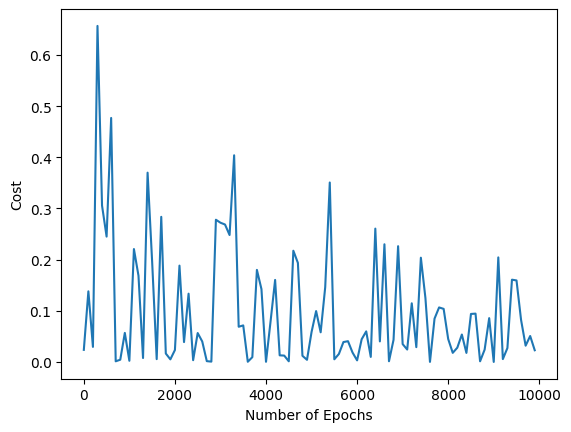

In [40]:
plt.xlabel("Number of Epochs")
plt.ylabel("Cost")
plt.plot(epoch_list_sgd, cost_list_sgd)

This plot visualizes the reduction in cost over the training epochs for Stochastic Gradient Descent. Due to the nature of SGD (using single samples), the cost function can fluctuate more significantly compared to Batch Gradient Descent, but it should generally show a downward trend.

In [42]:
predict(1575, 3, w_sgd, b_sgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(111.30137924821727)

## 9. Making Predictions with Stochastic Gradient Descent

Here, we use the `predict` function with the weights and bias (`w_sgd`, `b_sgd`) found by Stochastic Gradient Descent to estimate the price of a house with 1575 sqft and 3 bedrooms.

In [43]:
predict(2900, 3, w_sgd, b_sgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(167.56148814880038)

Another prediction example using the Stochastic Gradient Descent model for a house with 2900 sqft and 3 bedrooms.

In [44]:
predict(789, 5, w_sgd, b_sgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(144.91004433468194)

A final prediction example using the Stochastic Gradient Descent model for a house with 789 sqft and 5 bedrooms.